### OpenAI Whisper -> CNN -> Transformer -> Fully Connected -> Output

Goal is to try and replicate the architecture of OpenAI Whisper using a CNN and Transformer. Reference off the Automatic Speech Disfluency Detection Using wav2vec2.0 for Different Languages with Variable Lengths paper. 

In [ ]:
import pandas as pd
import torch
import librosa
import os
from transformers import WhisperFeatureExtractor, WhisperModel
from tqdm.notebook import tqdm # visualization
import numpy as np 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader # for training
from sklearn.utils.class_weight import compute_class_weight # class weights
from sklearn.model_selection import train_test_split # split data
from sklearn.preprocessing import LabelEncoder #transform labels
import matplotlib.pyplot as plt # visualization
import seaborn as sns # visualization
from sklearn.metrics import confusion_matrix, classification_report # visualization
import copy # copy and save model 
import math
import gc

In [ ]:
df = pd.read_csv('../Training/SEP-28k-Extended_clips.csv')

# 2. Define the columns that represent types of disfluency
disfluency_cols = ['Prolongation', 'Block', 'SoundRep', 'WordRep', 'Interjection']

# Filter the dataframe 
# .eq(3) checks for exactly 3, and .any(axis=1) checks across the columns for each row.
absolute_labels_df = df[df[disfluency_cols].eq(3).any(axis=1)].copy()

# file path map
absolute_labels_df['audio_path'] = (
    'SEP-28k_CLIP/' + 
    absolute_labels_df['Show'] + '/' + 
    absolute_labels_df['EpId'].astype(str) + '/' + 
    absolute_labels_df['Show'] + '_' + 
    absolute_labels_df['EpId'].astype(str) + '_' + 
    absolute_labels_df['ClipId'].astype(str) + '.wav'
)

# target labels with only 3
def get_absolute_label(row):
    for col in disfluency_cols:
        if row[col] == 3:
            return col
    return None

absolute_labels_df['target_label'] = absolute_labels_df.apply(get_absolute_label, axis=1)

print(f"Original rows: {len(df)}")
print(f"Filtered rows (absolute agreement): {len(absolute_labels_df)}\n")
print(absolute_labels_df[['audio_path', 'target_label', 'Prolongation', 'Block', 'SoundRep', 'WordRep', 'Interjection']].head())

Original rows: 28177
Filtered rows (absolute agreement): 6767

                                       audio_path  target_label  Prolongation  \
27  SEP-28k_CLIP/HeStutters/0/HeStutters_0_27.wav      SoundRep             0   
43   SEP-28k_CLIP/HeStutters/1/HeStutters_1_3.wav  Interjection             0   
45   SEP-28k_CLIP/HeStutters/1/HeStutters_1_5.wav       WordRep             0   
47   SEP-28k_CLIP/HeStutters/1/HeStutters_1_7.wav       WordRep             0   
54  SEP-28k_CLIP/HeStutters/1/HeStutters_1_14.wav  Prolongation             3   

    Block  SoundRep  WordRep  Interjection  
27      1         3        1             1  
43      1         0        0             3  
45      0         0        3             1  
47      0         0        3             0  
54      0         0        0             3  


In [ ]:
df = absolute_labels_df.copy() 

# clean the IDs ex: '0.0' become '0'
df['EpId_clean'] = df['EpId'].astype(float).astype(int).astype(str)
df['ClipId_clean'] = df['ClipId'].astype(float).astype(int).astype(str)

# file path (../SEP-28k_CLIP) 
df['audio_path'] = (
    "../SEP-28k_CLIP/" + 
    df['Show'].astype(str) + "/" + 
    df['EpId_clean'] + "/" + 
    df['Show'].astype(str) + "_" + 
    df['EpId_clean'] + "_" + 
    df['ClipId_clean'] + ".wav"
)

# check for file path
test_path = df['audio_path'].iloc[0]
print(f"🔍 Checking first file at: {os.path.abspath(test_path)}")
if not os.path.exists(test_path):
    print("❌ ERROR: File STILL not found! Please stop and double-check your folder structure.")
else:
    print("✅ File found! Pathing is correct.\n")

# Set up the Whisper Model
model_name = "openai/whisper-base"
feature_extractor = WhisperFeatureExtractor.from_pretrained(model_name)
model = WhisperModel.from_pretrained(model_name)

# find Mac GPU, also allowed for NVIDIA GPU
if torch.backends.mps.is_available():
    device = "mps"
    print("Using Mac GPU (MPS) for acceleration!")
elif torch.cuda.is_available():
    device = "cuda"
    print("Using NVIDIA GPU (CUDA) for acceleration!")
else:
    device = "cpu"
    print("Using CPU. (No GPU detected)")

model.to(device)

def get_whisper_embedding_sequence(audio_path):
    if not os.path.exists(audio_path): return None
    try:
        # Load audio at 16k Hz
        speech_array, sampling_rate = librosa.load(audio_path, sr=16000)
        inputs = feature_extractor(speech_array, sampling_rate=16000, return_tensors="pt")
        input_features = inputs.input_features.to(device)
        
        with torch.no_grad():
            encoder_outputs = model.encoder(input_features)
            
        # remove squeeze dimension
        embedding = encoder_outputs.last_hidden_state.squeeze(0).cpu().numpy()
        return embedding 
    except Exception as e:
        print(f"Error: {e}")
        return None

# Process the files
print(f"Processing audio files into sequences...")
all_embeddings = []
valid_indices = []

for idx, path in tqdm(enumerate(df['audio_path']), total=len(df)):
    emb = get_whisper_embedding_sequence(path) 
    
    if emb is not None:
        all_embeddings.append(emb)
        valid_indices.append(idx)

# Save as a true 3D Numpy Array
# (Samples, 150, 512)
np.save('whisper_embeddings.npy', np.array(all_embeddings))


clean_df = df.iloc[valid_indices].copy()
clean_df.to_csv('SEP-28k_with_paths.csv', index=False)
print(f"🎉 Finished! Shape saved: {np.array(all_embeddings).shape}")

🔍 Checking first file at: /Users/jaskirtkaler/Github Repo/disfluency_detection/SEP-28k_CLIP/HeStutters/0/HeStutters_0_27.wav
✅ File found! Pathing is correct.



Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

🚀 Using Mac GPU (MPS) for acceleration!
Processing audio files into sequences...


  0%|          | 0/6767 [00:00<?, ?it/s]

🎉 Finished! Shape saved: (6767, 1500, 512)


### MODEL


In [ ]:
print("Loading data...")
X_raw = np.load('whisper_embeddings.npy') 

# Slice to 3 seconds (150 tokens) to remove 1,350 tokens of silence
# "memory footprint" from 12GB to ~1.2GB I had AI help me with this
X = X_raw[:, :150, :] 

# Free up the old memory immediately
print(f"Original Shape: {X_raw.shape} | Optimized Shape: {X.shape}")
del X_raw
gc.collect() 

df = pd.read_csv('SEP-28k_with_paths.csv')
y_text = df['target_label'].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
num_classes = len(label_encoder.classes_)

# Split off 20% for Test, then 25% of 80% for Val
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Convert to Tensors (Directly onto CPU first, then DataLoaders handle device move)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)

print(f"🎉 Memory Cleaned. Data Splits -> Train: {len(X_train)} | Val: {len(X_val)}")

# Cnn + transformer

class TemporalCNNEncoder(nn.Module):
    def __init__(self):
        super(TemporalCNNEncoder, self).__init__()
        # Whisper base dim is 512. We treat these as "Channels" for the CNN
        self.conv1 = nn.Conv1d(in_channels=512, out_channels=256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(256)
        self.conv2 = nn.Conv1d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu = nn.GELU()
        self.pool = nn.MaxPool1d(kernel_size=2) 

    def forward(self, x):
        # x enters as [Batch, 150, 512]. Conv1d: [Batch, Channels, Time]
        x = x.transpose(1, 2) 
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        return x.transpose(1, 2) # Returns [Batch, 75, 128] for Transformer

class TransformerBrain(nn.Module):
    def __init__(self, num_classes, d_model=128, seq_length=75):
        super(TransformerBrain, self).__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_length, d_model) * 0.01)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512, dropout=0.3, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = x.mean(dim=1) 
        return self.fc(x)

class EndToEndStutterModel(nn.Module):
    def __init__(self, num_classes):
        super(EndToEndStutterModel, self).__init__()
        self.cnn = TemporalCNNEncoder()
        self.transformer = TransformerBrain(num_classes)

    def forward(self, x):
        return self.transformer(self.cnn(x))


# training and weights 
device = "mps" if torch.backends.mps.is_available() else "cpu"

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

model = EndToEndStutterModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)

epochs = 100
patience = 15
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = copy.deepcopy(model.state_dict())


# training 
print(f"Starting training on {device}...")

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val
    print(f"Epoch {epoch+1:02d} | Train Loss: {running_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n🛑 Early stopping triggered at Epoch {epoch+1}!")
            model.load_state_dict(best_model_weights)
            break
 
print("\n🎉 Training complete!")

Loading data...
Original Shape: (6767, 1500, 512) | Optimized Shape: (6767, 150, 512)
🎉 Memory Cleaned. Data Splits -> Train: 4059 | Val: 1354
Starting training on mps...
Epoch 01 | Train Loss: 0.9298 | Val Loss: 0.7945 | Val Acc: 76.66%
Epoch 02 | Train Loss: 0.6672 | Val Loss: 0.7594 | Val Acc: 82.42%
Epoch 03 | Train Loss: 0.5600 | Val Loss: 0.7241 | Val Acc: 82.64%
Epoch 04 | Train Loss: 0.4608 | Val Loss: 0.7535 | Val Acc: 80.21%
Epoch 05 | Train Loss: 0.4198 | Val Loss: 0.7910 | Val Acc: 79.39%
Epoch 06 | Train Loss: 0.3490 | Val Loss: 0.8692 | Val Acc: 80.50%
Epoch 07 | Train Loss: 0.2769 | Val Loss: 1.1131 | Val Acc: 80.87%
Epoch 08 | Train Loss: 0.2214 | Val Loss: 1.0409 | Val Acc: 80.28%
Epoch 09 | Train Loss: 0.1666 | Val Loss: 1.2171 | Val Acc: 78.66%
Epoch 10 | Train Loss: 0.1607 | Val Loss: 1.2825 | Val Acc: 78.88%
Epoch 11 | Train Loss: 0.1786 | Val Loss: 1.2572 | Val Acc: 80.65%
Epoch 12 | Train Loss: 0.0935 | Val Loss: 1.3819 | Val Acc: 81.31%
Epoch 13 | Train Loss: 0.

### RUN TEST OF MODEL


In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoader
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

# Evaluate
model.eval()
all_preds = []
all_labels = []

print("Evaluating on the completely unseen Test Set...")

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

test_acc = 100 * (np.array(all_preds) == np.array(all_labels)).sum() / len(all_labels)
print(f"\n🎉 Final Test Accuracy: {test_acc:.2f}%")

Evaluating on the completely unseen Test Set...

🎉 Final Test Accuracy: 80.72%


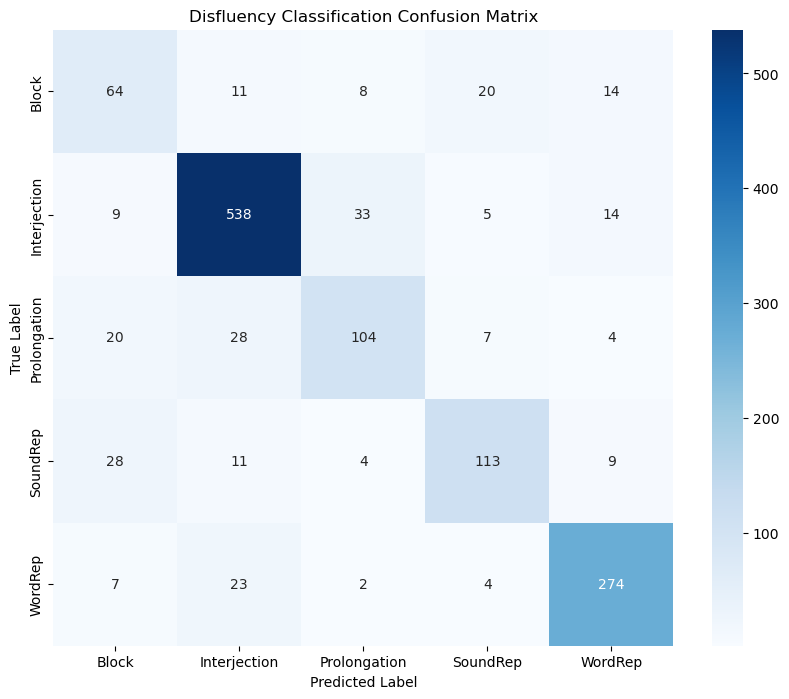


Detailed Classification Report:
              precision    recall  f1-score   support

       Block       0.50      0.55      0.52       117
Interjection       0.88      0.90      0.89       599
Prolongation       0.69      0.64      0.66       163
    SoundRep       0.76      0.68      0.72       165
     WordRep       0.87      0.88      0.88       310

    accuracy                           0.81      1354
   macro avg       0.74      0.73      0.73      1354
weighted avg       0.81      0.81      0.81      1354



In [10]:
cm = confusion_matrix(all_labels, all_preds)

class_names = label_encoder.classes_

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Disfluency Classification Confusion Matrix')
plt.show()

# (Precision, Recall, F1)
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))